In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
BASE_PATH = "/content/drive/MyDrive/Dataset"

TRAIN_CSV = f"{BASE_PATH}/train/train/labels.csv"
TEST_CSV = f"{BASE_PATH}/test/test/labels.csv"

TRAIN_IMAGES = f"{BASE_PATH}/train/train/rgb-front"
TEST_IMAGES = f"{BASE_PATH}/test/test/images"


In [5]:
#load dataset
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

/content/drive/MyDrive/Dataset/train/train/rgb-front/000000.jpg


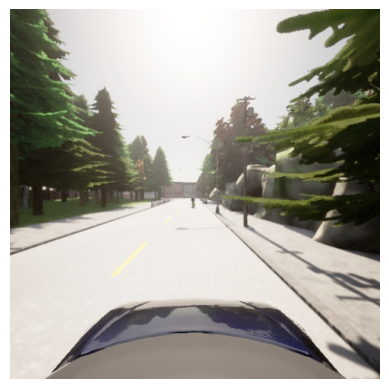

In [6]:
#load images from drive
import os
from PIL import Image
import matplotlib.pyplot as plt

frame_id = train_df.iloc[0]["frame"]

image_name = "000000.jpg"

img_path = os.path.join(TRAIN_IMAGES, image_name)
print(img_path)
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
#create label combnations
train_df["combo"] = (
    train_df["has_traffic_light"].astype(str) + "_" +
    train_df["has_pedestrian"].astype(str) + "_" +
    train_df["has_vehicle"].astype(str)
)
print(train_df["combo"].value_counts())

combo
True_False_True      3040
True_True_True       1125
False_False_True     1063
True_False_False      832
False_False_False     547
True_True_False       279
False_True_True       230
False_True_False       84
Name: count, dtype: int64


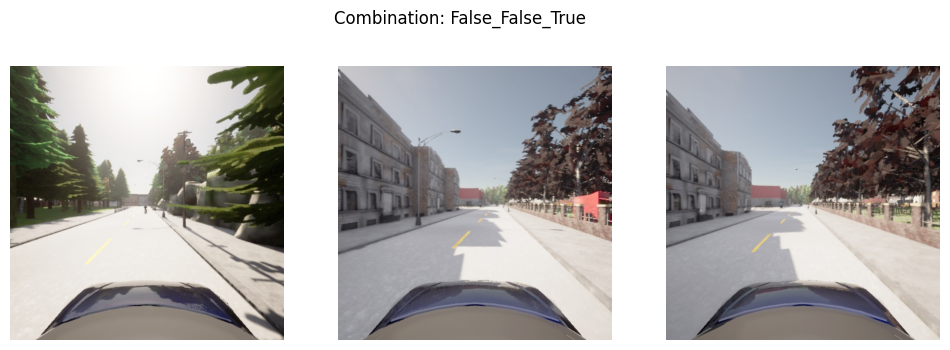

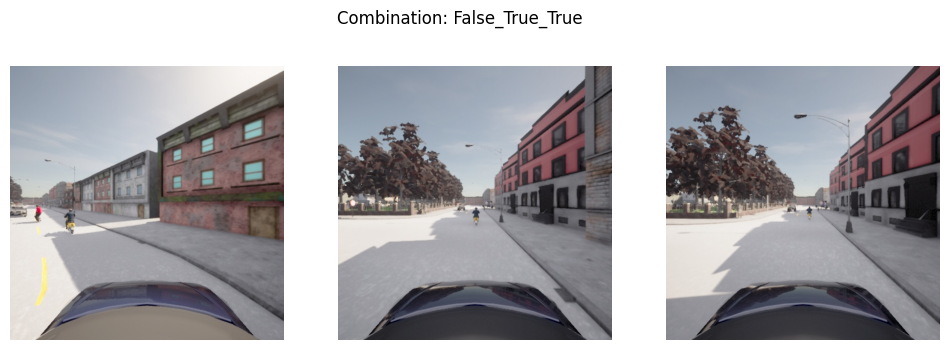

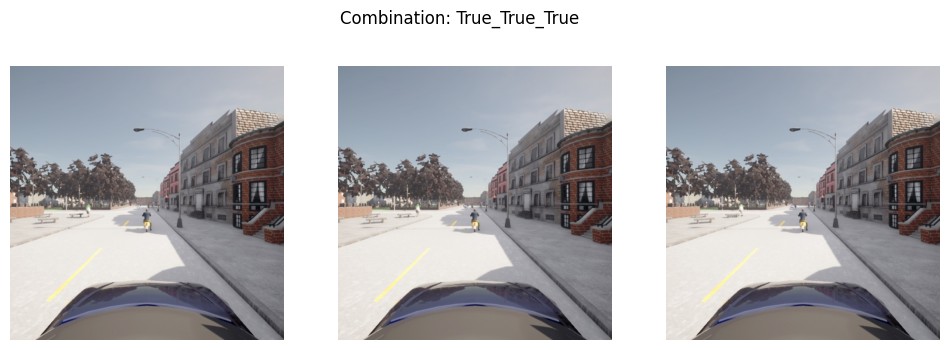

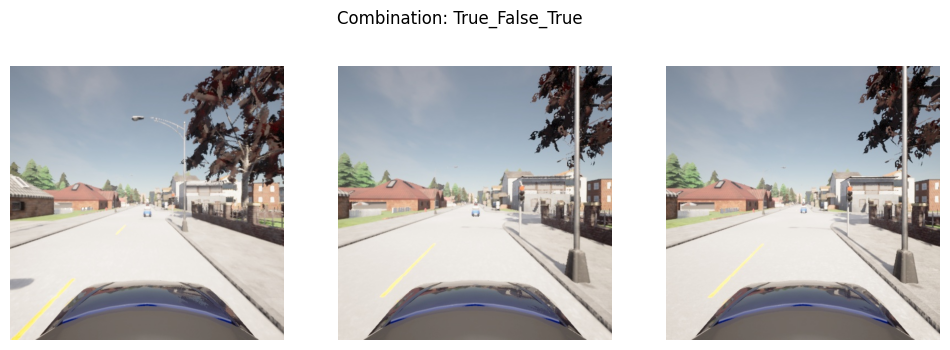

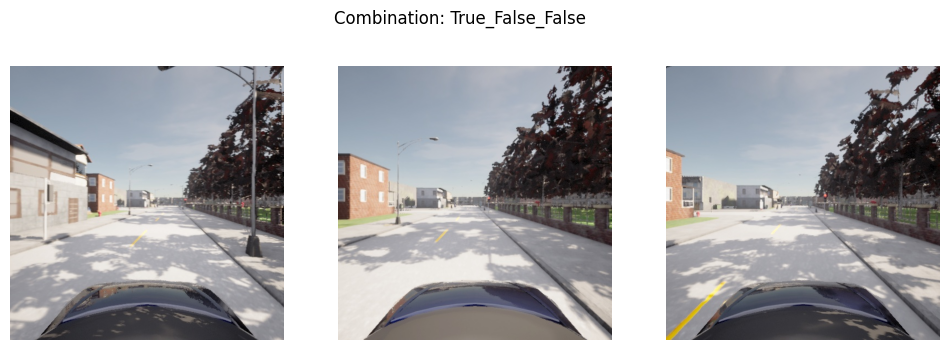

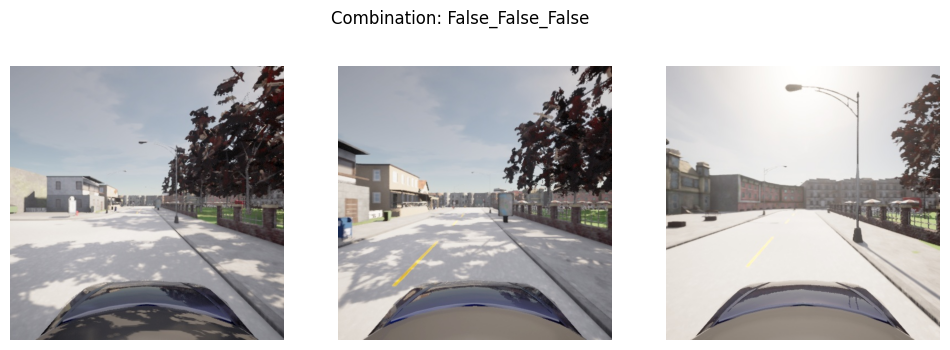

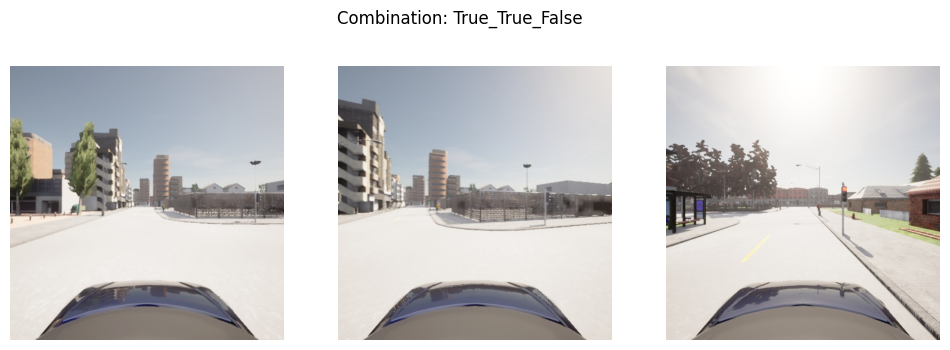

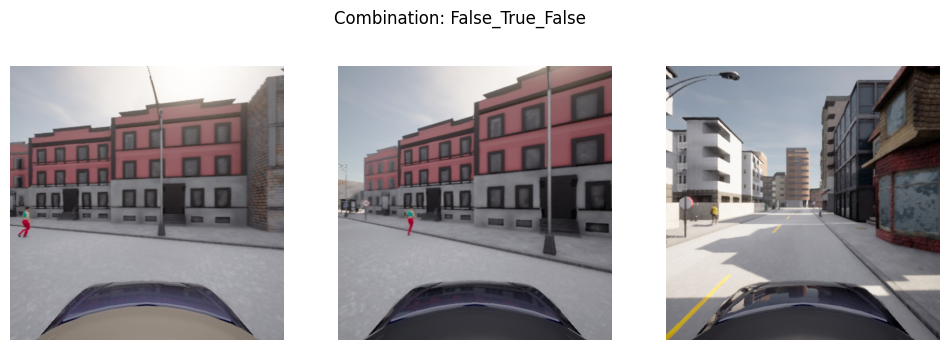

In [8]:
#for each combo displaying images
combinations = train_df["combo"].unique()

for combo in combinations:

    subset = train_df[train_df["combo"] == combo]

    fig, axes = plt.subplots(1, 3, figsize=(12,4))

    fig.suptitle(f"Combination: {combo}")

    for i in range(min(3, len(subset))):

        row = subset.iloc[i]

        frame_id = row["frame"]

        image_name = f"{str(frame_id).zfill(6)}.jpg"

        img_path = os.path.join(TRAIN_IMAGES, image_name)

        img = Image.open(img_path)

        axes[i].imshow(img)
        axes[i].axis("off")

    plt.show()

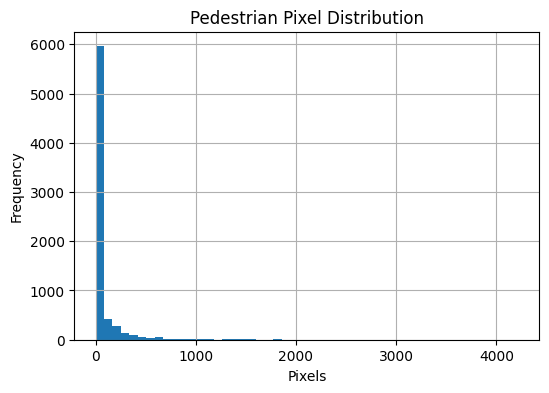

In [18]:
#histogram for pedestrian pixel
plt.figure(figsize=(6,4))

train_df["px_pedestrian"].hist(bins=50)

plt.title("Pedestrian Pixel Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")

plt.show()

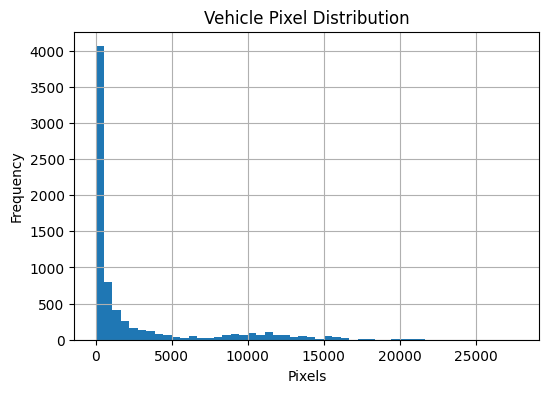

In [19]:
#histogram for vehicle pixel
plt.figure(figsize=(6,4))

train_df["px_vehicle"].hist(bins=50)

plt.title("Vehicle Pixel Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")

plt.show()

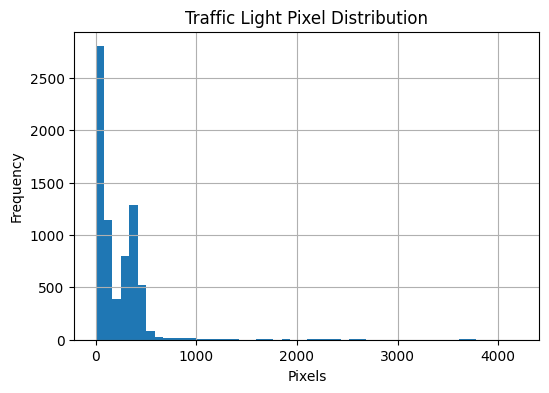

In [20]:
#histogram for traffic light pixel
plt.figure(figsize=(6,4))

train_df["px_traffic_light"].hist(bins=50)

plt.title("Traffic Light Pixel Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")

plt.show()

In [9]:
#no of images in training and test splits
print("Total images in training set :", len(train_df))
print("Total images in test set :", len(test_df))

Total images in training set : 7200
Total images in test set : 3600


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   frame              7200 non-null   int64 
 1   has_traffic_light  7200 non-null   bool  
 2   has_pedestrian     7200 non-null   bool  
 3   has_vehicle        7200 non-null   bool  
 4   px_traffic_light   7200 non-null   int64 
 5   px_pedestrian      7200 non-null   int64 
 6   px_vehicle         7200 non-null   int64 
 7   combo              7200 non-null   object
dtypes: bool(3), int64(4), object(1)
memory usage: 302.5+ KB


In [12]:
train_df.describe() #statistical info

,frame,px_traffic_light,px_pedestrian,px_vehicle
count,7200.000000,7200.000000,7200.000000,7200.000000
mean,35995.000000,218.503611,70.369306,2259.733889
std,20786.053016,310.809585,217.723742,4085.054794
min,0.000000,0.000000,0.000000,0.000000
25%,17997.500000,33.000000,0.000000,44.000000
50%,35995.000000,136.000000,2.000000,363.000000
75%,53992.500000,343.000000,34.000000,1892.250000
max,71990.000000,4199.000000,4219.000000,27791.000000


In [13]:
train_df.isnull().sum() #check if training set has any null values


,0
frame,0
has_traffic_light,0
has_pedestrian,0
has_vehicle,0
px_traffic_light,0
px_pedestrian,0
px_vehicle,0
combo,0


has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


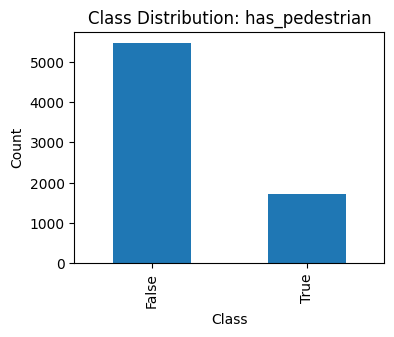

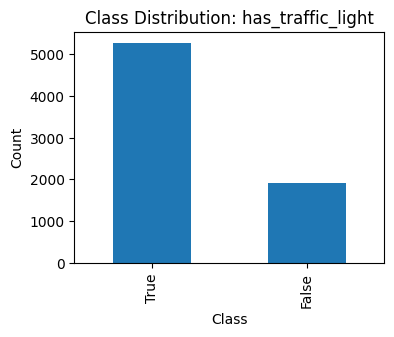

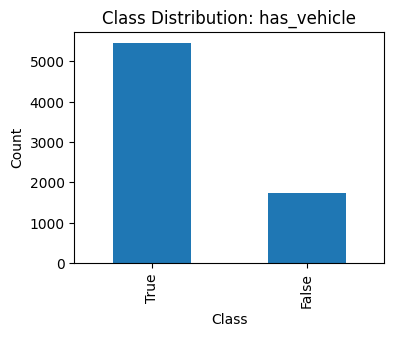

In [16]:
#class distribution
print(train_df["has_pedestrian"].value_counts())
print(train_df["has_traffic_light"].value_counts())
print(train_df["has_vehicle"].value_counts())
labels = ["has_pedestrian", "has_traffic_light", "has_vehicle"]

for label in labels:

    plt.figure(figsize=(4,3))

    train_df[label].value_counts().plot(kind='bar')

    plt.title(f"Class Distribution: {label}")

    plt.xlabel("Class")
    plt.ylabel("Count")

    plt.show()

In [21]:
#Safety-Oriented Observations
#- The dataset mainly contains daytime urban driving scenes.
#- Weather conditions are mostly clear and sunny.
#- Camera position is fixed and front-facing.
#- Vehicles appear much more frequently than pedestrians.
#- Traffic lights often appear near intersections.
#- Environmental diversity is limited.
#- No nighttime, fog, snow, or heavy rain scenes are visible.

#Important ML Safety Interpretation
#The training distribution is narrow.
#The models may perform poorly outside the observed conditions.
#No safety claims can be made for nighttime, rain, fog, snow, or rural environments.